# Feature marque — extraction + premium + comparaison d'encodages

La baseline (notebook 02) **sous-estime le haut de gamme** car la marque est ignorée.
Ici on extrait la **marque** depuis `carmodel` et on la relie au prix de **deux façons**, puis on compare.

**Pièges gérés :**
- Marques multi-mots (`ALFA ROMEO`, `LAND ROVER`, `ASTON MARTIN`) — extraction par correspondance avec une liste connue, pas « premier mot ».
- Classification premium en **3 paliers** (table `ml/references/premium_brand.csv`).

**Deux relations marque → nombre comparées :**
- **A. Palier premium ordinal** (0/1/2) — fait main, interprétable.
- **B. Prix moyen par marque** (target encoding) — appris des données, calculé **sur le train seulement** (anti-fuite).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")   # accès au code partagé ml/src/

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import load_premium_table, add_brand_features

df = pd.read_csv("../../data/french-second-hand-cars/processed/cars_clean.csv")
ref = load_premium_table("../../references/premium_brand.csv")
print("données:", df.shape, "| marques référencées:", len(ref))

données: (2340, 11) | marques référencées: 44


## 🟦 1. PRÉPROCESSING — extraction marque + palier premium

In [2]:
df = add_brand_features(df, ref)   # ajoute marque, palier, niveau
print("marques non reconnues :", df["marque"].isna().sum())
print(df["palier"].value_counts().to_dict())
df[["carmodel", "marque", "palier", "niveau"]].head(3)

marques non reconnues : 0
{'generaliste': 1451, 'premium': 775, 'luxe': 114}


,carmodel,marque,palier,niveau
0,\n RENAULT TWINGO 3\n,RENAULT,generaliste,0
1,\n BMW SERIE 4 F36 GRAN COUPE\n,BMW,premium,1
2,\n BMW SERIE 2 F45 ACTIVE TOURER\n,BMW,premium,1


## 🟦 2. PRÉPROCESSING — features de base + split train/test

Socle commun aux 3 modèles : les 6 features numériques de la baseline.
Même `random_state=42` → comparaison équitable.

In [3]:
base = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
        "nombredeportes", "nombredeplaces"]
data = df[base + ["price", "marque", "niveau"]].dropna(subset=base + ["price"])
print(f"lignes utilisables : {len(data)}")

train, test = train_test_split(data, test_size=0.2, random_state=42)
y_train, y_test = train["price"], test["price"]
print("train:", len(train), "| test:", len(test))

lignes utilisables : 2229
train: 1783 | test: 446


## 🟦 3. PRÉPROCESSING — encodage B : prix moyen par marque (anti-fuite)

Le prix moyen de chaque marque est calculé **sur le train uniquement**.
Une marque du test absente du train reçoit la **moyenne globale du train** (fallback).
👉 Calculer cette moyenne sur tout le dataset serait une **fuite** (le test influencerait l'entraînement).

In [4]:
prix_moyen_marque = train.groupby("marque")["price"].mean()
global_mean = train["price"].mean()

train = train.assign(marque_prix_moyen=train["marque"].map(prix_moyen_marque))
test  = test.assign(marque_prix_moyen=test["marque"].map(prix_moyen_marque).fillna(global_mean))

print("ex. prix moyen appris (train) :")
print(prix_moyen_marque.sort_values(ascending=False).head(5).round(0).to_dict())

ex. prix moyen appris (train) :
{'FERRARI': 166572.0, 'PORSCHE': 112502.0, 'ASTON MARTIN': 99020.0, 'LOTUS': 91280.0, 'MASERATI': 76846.0}


## 🟩 4. ENTRAÎNEMENT + 🟥 ÉVALUATION — 3 modèles comparés

- **Baseline** : 6 features numériques.
- **+ palier** : baseline + niveau premium (0/1/2).
- **+ prix moyen marque** : baseline + target encoding.

In [5]:
def evaluer(feats, nom):
    model = LinearRegression().fit(train[feats], y_train)
    pred = model.predict(test[feats])
    return {
        "modèle": nom,
        "MAE (€)": round(mean_absolute_error(y_test, pred)),
        "RMSE (€)": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R²": round(r2_score(y_test, pred), 3),
    }

resultats = pd.DataFrame([
    evaluer(base, "baseline (6 num)"),
    evaluer(base + ["niveau"], "+ palier premium"),
    evaluer(base + ["marque_prix_moyen"], "+ prix moyen marque"),
])
resultats

,modèle,MAE (€),RMSE (€),R²
0,baseline (6 num),7711,14815,0.717
1,+ palier premium,7556,14279,0.737
2,+ prix moyen marque,6496,11909,0.817


## 🟥 5. Effet sur le haut de gamme (scatter comparatif)

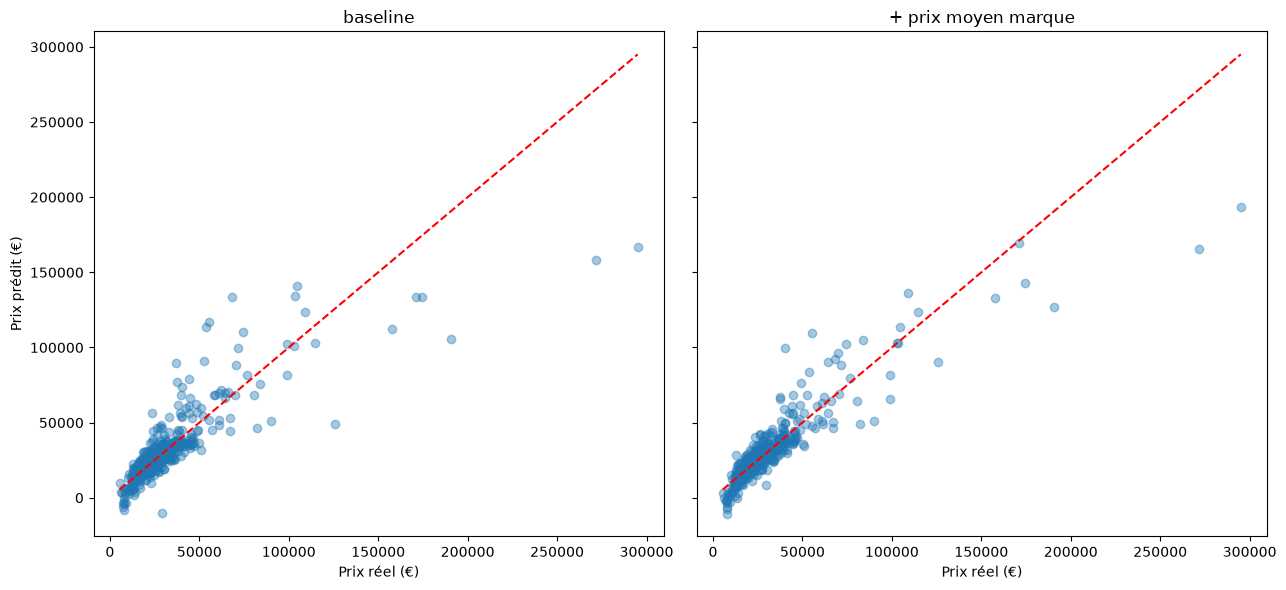

In [6]:
import matplotlib.pyplot as plt

m_base = LinearRegression().fit(train[base], y_train)
m_best = LinearRegression().fit(train[base + ["marque_prix_moyen"]], y_train)
p_base = m_base.predict(test[base])
p_best = m_best.predict(test[base + ["marque_prix_moyen"]])

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
lims = [y_test.min(), y_test.max()]
for a, pred, titre in [(ax[0], p_base, "baseline"), (ax[1], p_best, "+ prix moyen marque")]:
    a.scatter(y_test, pred, alpha=0.4)
    a.plot(lims, lims, "r--")
    a.set_xlabel("Prix réel (€)"); a.set_title(titre)
ax[0].set_ylabel("Prix prédit (€)")
plt.tight_layout(); plt.show()

## Lecture

- Le **palier premium** (interprétable, 1 coef lisible) vs le **prix moyen marque** (plus prédictif) illustrent le **compromis interprétabilité / performance** (cf. `alyra-brain`).
- Attendu : le target encoding réduit le cône (moins de sous-estimation du premium/luxe).
- Limites : le linéaire reste limité (dépréciation non linéaire) → piste suivante = modèle non linéaire (RandomForest).
- Toujours pas de **fourchette + incertitude** (exigence produit à venir).